In [1]:
import kagglehub
import os
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Dataset path:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset path: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [3]:
file_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(file_path)

print(df.head())
print("\nDataset size:", df.shape)


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset size: (50000, 2)


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['review'] = df['review'].apply(clean_text)

In [5]:
df = df.sample(10000, random_state=42)

X = df['review']
y = df['sentiment']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)


svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

LinearSVC()

In [9]:
nb_pred = nb_model.predict(X_test_vec)
print("\nNaive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

svm_pred = svm_model.predict(X_test_vec)
print("\nSVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


Naive Bayes Accuracy: 0.846
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85       999
    positive       0.85      0.84      0.84      1001

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


SVM Accuracy: 0.866
              precision    recall  f1-score   support

    negative       0.89      0.84      0.86       999
    positive       0.85      0.89      0.87      1001

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



In [10]:
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])

    nb_result = nb_model.predict(vec)[0]
    svm_result = svm_model.predict(vec)[0]

    print("\nInput:", text)
    print("Naive Bayes:", nb_result)
    print("SVM:", svm_result)

In [11]:
predict_sentiment("This movie was absolutely amazing and fantastic!")
predict_sentiment("Worst movie ever, I hated it completely")


Input: this movie was absolutely amazing and fantastic
Naive Bayes: positive
SVM: positive

Input: worst movie ever i hated it completely
Naive Bayes: negative
SVM: negative


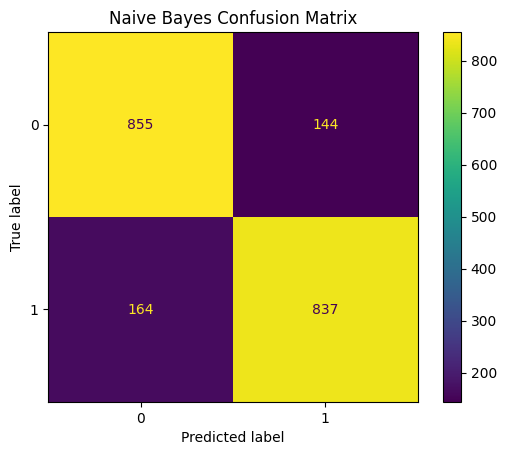

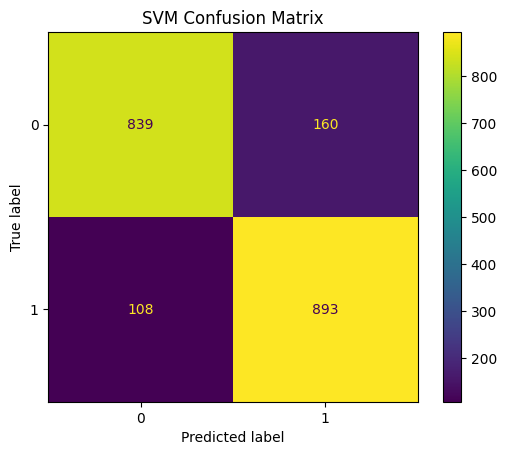

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Naive Bayes
cm_nb = confusion_matrix(y_test, nb_pred)
ConfusionMatrixDisplay(cm_nb).plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# SVM
cm_svm = confusion_matrix(y_test, svm_pred)
ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

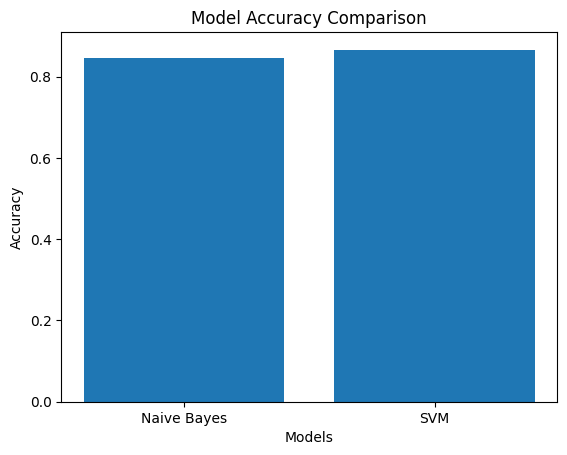

In [13]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'SVM']
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [14]:
from sklearn.pipeline import Pipeline

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('nb', MultinomialNB())
])


nb_pipeline.fit(X_train, y_train)


nb_pred_pipe = nb_pipeline.predict(X_test)

print("Pipeline NB Accuracy:", accuracy_score(y_test, nb_pred_pipe))

Pipeline NB Accuracy: 0.846


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(LinearSVC(), param_grid, cv=3)
grid.fit(X_train_vec, y_train)

print("Best Parameters:", grid.best_params_)

best_svm = grid.best_estimator_

# Evaluate
best_pred = best_svm.predict(X_test_vec)
print("Tuned SVM Accuracy:", accuracy_score(y_test, best_pred))

Best Parameters: {'C': 0.1}
Tuned SVM Accuracy: 0.8715
